# Perturb-Seqr: Drug vs. Gene Enrichment Analysis of Top Mimickers/Reversers

Given an up/down gene signature, this notebook:

1. Runs a **paired up/down enrichment** search against Perturb-Seqr to find **mimicking** (same-direction) and **reversing** (opposite-direction) perturbations.
2. Splits the results into **drug/chemical perturbations** vs. **gene perturbations** using the dataset/library each hit came from (per the Perturb-Seqr skill's documented approach).
3. Reports the top drug mimickers, top gene mimickers, top drug reversers, and top gene reversers separately — both as robust **consensus** hits (aggregated across datasets) and as **individual per-dataset** hits (comparable to the Perturb-Seqr website's default table).

Replace `GENES_UP` / `GENES_DOWN` below with your own signature — the example here is a small illustrative TP53-associated signature.

In [1]:
!pip install -q requests pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

PERTURBSEQR_URL = "https://perturbseqr.maayanlab.cloud/graphql"

# ---- Example signature (replace with your own up/down gene lists) ----
GENES_UP = [
    "CDKN1A", "MDM2", "BAX", "GADD45A", "SESN1", "RRM2B", "BBC3", "TP53I3",
    "FAS", "PMAIP1", "ZMAT3", "TNFRSF10B", "BTG2", "PLK3", "TIGAR", "SFN",
]
GENES_DOWN = [
    "MYC", "CCND1", "CCNB1", "CDK1", "CDC20", "PLK1", "BIRC5", "AURKA",
    "TOP2A", "MKI67", "BUB1", "CCNE2", "E2F1", "MCM2", "PCNA", "RRM2",
]

print(f"Up genes ({len(GENES_UP)}): {GENES_UP}")
print(f"Down genes ({len(GENES_DOWN)}): {GENES_DOWN}")

Up genes (16): ['CDKN1A', 'MDM2', 'BAX', 'GADD45A', 'SESN1', 'RRM2B', 'BBC3', 'TP53I3', 'FAS', 'PMAIP1', 'ZMAT3', 'TNFRSF10B', 'BTG2', 'PLK3', 'TIGAR', 'SFN']
Down genes (16): ['MYC', 'CCND1', 'CCNB1', 'CDK1', 'CDC20', 'PLK1', 'BIRC5', 'AURKA', 'TOP2A', 'MKI67', 'BUB1', 'CCNE2', 'E2F1', 'MCM2', 'PCNA', 'RRM2']


## Step 1: Query Perturb-Seqr — paired up/down enrichment

In [14]:
def parse_perturbation_term(term):
    """
    Perturb-Seqr packs the perturbation name together with metadata (cell line, tissue,
    dose, KO/KD/Mut label, dataset ID, gene set size, etc.) in the 'term' string, separated
    by '::'. The perturbation name is always the first '::'-delimited field; everything
    after is metadata. The direction ('up'/'down'), when present, is the last
    whitespace-separated token of the *last* '::' field.

    Examples:
        >>> parse_perturbation_term("TP53::CAL51::::::::KO::::SRP287851::2996 down")
        ('TP53', 'down')
        >>> parse_perturbation_term("doxorubicin::::human dermal fibroblast::24h::0.3uM")
        ('doxorubicin', None)
    """
    fields = term.split("::")
    perturbation = fields[0].strip()
    last_field = fields[-1].strip() if fields else ""
    tokens = last_field.split(" ")
    direction = tokens[-1].lower() if len(tokens) > 1 and tokens[-1].lower() in ("up", "down") else None
    return perturbation, direction


def enrich_perturbseqr_up_down(genes_up: list, genes_down: list, first: int = 10000, topN: int = 10000, sort_by: str = "pvalue_mimic"):
    """Paired up/down gene set enrichment against Perturb-Seqr (validated GraphQL schema).

    `first` controls how many individual result rows the server returns, while `topN` is a
    separate filtering threshold. `sort_by` controls which direction the server sorts by
    *before* slicing to `first` -- if the true total (see `totalCount` in the response)
    exceeds `first`, only the requested direction's top rows are guaranteed to be complete.
    E.g. if `sort_by='pvalue_mimic'`, the returned `nodes` are the correct top-`first` by
    mimic p-value, but locally re-sorting that same slice by pvalueReverse can miss true top
    reversers that fall outside the window. Call this once per direction you need a
    complete/correct top-N for (see the mimicker/reverser query cells below).

    IMPORTANT -- library domination: `pairedEnrich` has no per-library filter (that only
    exists on the single-set enrichment query), so `first`/`topN` cap a single *global*
    ranking across every library combined. A library with many entries and very extreme
    p-values (e.g. LINCS L1000 CP) can completely crowd a smaller library (e.g. SciPlex) out
    of the window even when that smaller library has its own genuinely significant hits --
    the smaller library ends up with *zero* rows in the result, not just a few. Raising
    `first`/`topN` (as done here, from 1000 to 5000) gives smaller libraries more room to
    surface; if a library is still completely missing afterward, check the printed
    total-vs-returned warning below -- if the server's `totalCount` still exceeds what's
    returned, `first` may need to go even higher for that specific gene signature.
    """
    query = {
        "operationName": "PairEnrichmentQuery",
        "variables": {
            "filterTerm": "",
            "offset": 0,
            "first": first,
            "filterFda": False,
            "sortBy": sort_by,
            "filterKo": False,
            "topN": topN,
            "pvalueLe": 0.05,
            "genesUp": genes_up,
            "genesDown": genes_down,
        },
        "query": """query PairEnrichmentQuery($genesUp: [String]!, $genesDown: [String]!, $filterTerm: String = \"\", $offset: Int = 0, $first: Int = 10, $filterFda: Boolean = false, $sortBy: String = \"\", $filterKo: Boolean = false, $topN: Int = 10000, $pvalueLe: Float = 0.05) {
  currentBackground {
    pairedEnrich(
      filterTerm: $filterTerm
      offset: $offset
      first: $first
      filterFda: $filterFda
      sortby: $sortBy
      filterKo: $filterKo
      topN: $topN
      pvalueLe: $pvalueLe
      genesDown: $genesDown
      genesUp: $genesUp
      ) {
        totalCount
        consensusCount
        consensus {
          drug
          oddsRatio
          pvalue
          adjPvalue
          approved
          countSignificant
          countInsignificant
          countUpSignificant
          pvalueUp
          adjPvalueUp
          oddsRatioUp
          pvalueDown
          adjPvalueDown
          oddsRatioDown
          libraries
          }
          nodes {
            adjPvalueMimic
            adjPvalueReverse
            mimickerOverlap
            oddsRatioMimic
            oddsRatioReverse
            pvalueMimic
            pvalueReverse
            reverserOverlap
            geneSet {
              nodes {
                id
                nGeneIds
                term
                geneSetFdaCountsById {
                  nodes {
                    count
                    approved
                    }
                  }
                library {
                  name
                  }
                }
              }
            }
          }
        }
      }
""",
    }

    response = requests.post(PERTURBSEQR_URL, json=query)
    if not response.ok:
        print(f"Perturb-Seqr request failed ({response.status_code}). Response body:")
        print(response.text[:2000])
    response.raise_for_status()
    res = response.json()

    consensus = res["data"]["currentBackground"]["pairedEnrich"]["consensus"]
    enrichment = res["data"]["currentBackground"]["pairedEnrich"]["nodes"]
    total_count = res["data"]["currentBackground"]["pairedEnrich"].get("totalCount")

    if total_count is not None and total_count > len(enrichment):
        print(
            f"NOTE: server reports {total_count} total qualifying gene-set matches for "
            f"sort_by='{sort_by}', but only {len(enrichment)} were returned (first={first}). "
            f"The returned rows are still the correct top-{len(enrichment)} for '{sort_by}' "
            "specifically (that's what server-side sorting is for) -- but don't reuse this same "
            "slice to rank the *other* direction (e.g. re-sorting a pvalue_mimic-sorted slice by "
            "pvalueReverse), since true top hits for the other direction can fall outside this window."
        )

    df_consensus_pair = pd.DataFrame(consensus).rename(
        columns={
            "drug": "perturbation",
            "pvalueUp": "pvalueMimic",
            "pvalueDown": "pvalueReverse",
            "adjPvalueUp": "adjPvalueMimic",
            "adjPvalueDown": "adjPvalueReverse",
            "oddsRatioUp": "oddsRatioMimic",
            "oddsRatioDown": "oddsRatioReverse",
        }
    )

    if not enrichment:
        return pd.DataFrame(), df_consensus_pair

    df_enrichment_pair = pd.DataFrame(enrichment)
    df_enrichment_pair["term"] = df_enrichment_pair["geneSet"].map(lambda t: parse_perturbation_term(t["nodes"][0]["term"])[0])
    df_enrichment_pair["approved"] = df_enrichment_pair["geneSet"].map(
        lambda t: t["nodes"][0]["geneSetFdaCountsById"]["nodes"][0]["approved"]
        if t["nodes"][0]["geneSetFdaCountsById"]["nodes"]
        else False
    )
    df_enrichment_pair["count"] = df_enrichment_pair["geneSet"].map(
        lambda t: t["nodes"][0]["geneSetFdaCountsById"]["nodes"][0]["count"]
        if t["nodes"][0]["geneSetFdaCountsById"]["nodes"]
        else 0
    )
    df_enrichment_pair["library"] = df_enrichment_pair["geneSet"].map(lambda t: t["nodes"][0]["library"]["name"])
    df_enrichment_pair["geneSetIdUp"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["id"] for node in t["nodes"] if " up" in node["term"]), None)
    )
    df_enrichment_pair["geneSetIdDown"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["id"] for node in t["nodes"] if " down" in node["term"]), None)
    )
    df_enrichment_pair["nGeneIdsUp"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["nGeneIds"] for node in t["nodes"] if " up" in node["term"]), None)
    )
    df_enrichment_pair["nGeneIdsDown"] = df_enrichment_pair["geneSet"].map(
        lambda t: next((node["nGeneIds"] for node in t["nodes"] if " down" in node["term"]), None)
    )

    df_enrichment_pair = df_enrichment_pair.drop(columns=["geneSet"])

    return df_enrichment_pair, df_consensus_pair


# We only have a *validated* sort value for one direction: "pvalue_mimic" (confirmed against
# the website earlier). Guessing "pvalue_reverse" turned out to be wrong/ignored by the server
# -- it returned rows with pvalueReverse as weak as 0.05-0.17, while the website's true top
# reversers go down to ~1e-14, meaning that query never actually retrieved them.
#
# Instead of guessing another sort string, we exploit a mathematical identity: a "reverser"
# for our real signature (up matches target-down, down matches target-up) is *exactly* a
# "mimicker" for the up/down-swapped signature. So querying with genesUp/genesDown swapped,
# sorted by the validated "pvalue_mimic", gives a guaranteed-correct, complete top-N ranking
# for what is really our reverser direction -- we just relabel the columns afterward.
df_enrichment_mimic, df_consensus_pair = enrich_perturbseqr_up_down(
    GENES_UP, GENES_DOWN, sort_by="pvalue_mimic"
)
df_enrichment_reverse_raw, _ = enrich_perturbseqr_up_down(
    GENES_DOWN, GENES_UP, sort_by="pvalue_mimic"
)

# Relabel the swapped query's *mimic* columns (trustworthy top-N) as our true *reverse*
# metrics. Target-side descriptive fields (term/library/nGeneIds*/approved/count/geneSetIds)
# describe the target dataset itself and don't depend on our query's up/down orientation, so
# they're left as-is. We drop the swapped query's own "reverse"-labeled columns since those
# correspond to the *original* mimic direction but computed from a differently-truncated
# slice -- we already have a trustworthy version of that from df_enrichment_mimic.
shared_cols = ["term", "library", "nGeneIdsUp", "nGeneIdsDown", "approved", "count",
               "geneSetIdUp", "geneSetIdDown"]
if not df_enrichment_reverse_raw.empty:
    df_enrichment_reverse = df_enrichment_reverse_raw[shared_cols].copy()
    df_enrichment_reverse["pvalueReverse"] = df_enrichment_reverse_raw["pvalueMimic"]
    df_enrichment_reverse["adjPvalueReverse"] = df_enrichment_reverse_raw["adjPvalueMimic"]
    df_enrichment_reverse["oddsRatioReverse"] = df_enrichment_reverse_raw["oddsRatioMimic"]
    df_enrichment_reverse["reverserOverlap"] = df_enrichment_reverse_raw["mimickerOverlap"]
else:
    df_enrichment_reverse = pd.DataFrame(columns=shared_cols + [
        "pvalueReverse", "adjPvalueReverse", "oddsRatioReverse", "reverserOverlap"
    ])

# Merge the trustworthy mimicker table and the trustworthy (relabeled) reverser table into
# one combined per-dataset table, matched on the target's own gene-set IDs. Use suffixes for
# the shared descriptive columns, then coalesce them (a row present in only one side would
# otherwise have missing term/library/etc. after an outer merge).
merge_cols = ["geneSetIdUp", "geneSetIdDown"]
descriptive_cols = ["term", "library", "nGeneIdsUp", "nGeneIdsDown", "approved", "count"]

df_enrichment_pair = pd.merge(
    df_enrichment_mimic.drop(columns=["pvalueReverse", "adjPvalueReverse", "oddsRatioReverse", "reverserOverlap"], errors="ignore"),
    df_enrichment_reverse,
    on=merge_cols,
    how="outer",
    suffixes=("", "_rev"),
)
for col in descriptive_cols:
    rev_col = f"{col}_rev"
    if rev_col in df_enrichment_pair.columns:
        df_enrichment_pair[col] = df_enrichment_pair[col].fillna(df_enrichment_pair[rev_col])
        df_enrichment_pair = df_enrichment_pair.drop(columns=[rev_col])

print(f"Found {len(df_enrichment_mimic)} rows (validated top-N for mimickers)")
print(f"Found {len(df_enrichment_reverse)} rows (validated top-N for reversers, via swapped query)")
print(f"Found {len(df_enrichment_pair)} combined individual (per-dataset) gene-set rows")
print(f"Found {len(df_consensus_pair)} consensus perturbations")

NOTE: server reports 13472 total qualifying gene-set matches for sort_by='pvalue_mimic', but only 10000 were returned (first=10000). The returned rows are still the correct top-10000 for 'pvalue_mimic' specifically (that's what server-side sorting is for) -- but don't reuse this same slice to rank the *other* direction (e.g. re-sorting a pvalue_mimic-sorted slice by pvalueReverse), since true top hits for the other direction can fall outside this window.
NOTE: server reports 13472 total qualifying gene-set matches for sort_by='pvalue_mimic', but only 10000 were returned (first=10000). The returned rows are still the correct top-10000 for 'pvalue_mimic' specifically (that's what server-side sorting is for) -- but don't reuse this same slice to rank the *other* direction (e.g. re-sorting a pvalue_mimic-sorted slice by pvalueReverse), since true top hits for the other direction can fall outside this window.
Found 10000 rows (validated top-N for mimickers)
Found 10000 rows (validated top-N

## Step 2: Classify each hit as a Drug or Gene perturbation

Per the Perturb-Seqr skill: enrichment/consensus results mix drugs and genes even when labels suggest otherwise, and `filterKo` is not reliable for separating them. The documented approach is to classify by which dataset/library each hit came from. We match on keyword substrings (case-insensitive) rather than exact full-string equality, since exact strings returned by the live API can vary slightly from the reference table.

In [15]:
DRUG_KEYWORDS = [
    "l1000 chemical",       # LINCS L1000 Chemical Perturbations (L2S2)
    "l1000 cp",              # "LINCS L1000 CP" -- abbreviated form seen in live API output
    "tahoe-100m",            # Tahoe-100M (Hugging Face)
    "nibr drug-seq",         # NIBR DRUG-seq U2OS MoABox Dataset (Harmonizome)
    "microarrays cmap",      # "Microarrays CMAP" -- live API name is shorter than the full ref. name
    "ginkgo bioworks",       # Ginkgo Bioworks (Hugging Face)
    "sciplex",               # SciPlex Drug Perturbations (Harmonizome)
    "deepcover moa",         # DeepCover MoA (Harmonizome)
    "creeds drug",           # CREEDS Drug Perturbations (CREEDS)
    "creeds chem",           # "CREEDS Chem" -- abbreviated form seen in live API output
    "rummageo drug",         # RummaGEO Drug Perturbations (Harmonizome)
    "rummageo chem",         # "RummaGEO Chem" -- live API uses 'Chem' not 'Drug'
    "rgeo chem",             # "RGEO Chem" -- further-abbreviated form seen in live API output
]

GENE_KEYWORDS = [
    "perturb atlas",         # Perturb Atlas Human/Mouse Gene Perturbations (Harmonizome)
    "patlas",                # "PAtlas Human" / "PAtlas Mouse" -- abbreviated form seen in live API output
    "l1000 gene knockouts",  # LINCS L1000 Gene Knockouts (L2S2)
    "l1000 xpr",             # "LINCS L1000 XPR" -- CRISPR knockout variant seen in live API output
    "replogle",              # Replogle Perturb-seq K562/RPE1 (Harmonizome)
    "creeds gene",           # CREEDS Gene Perturbations (CREEDS)
    "cm4ai",                 # Bridge2AI CM4AI (Perturb-seq)
    "rummageo gene",         # RummaGEO Gene Perturbations (Harmonizome)
    "rgeo gene",             # "RGEO Gene" -- abbreviated form seen in live API output
]


def classify_library(lib: str) -> str:
    lib = str(lib).strip().lower()
    is_drug = any(kw in lib for kw in DRUG_KEYWORDS)
    is_gene = any(kw in lib for kw in GENE_KEYWORDS)
    if is_drug and is_gene:
        return "drug+gene"
    if is_drug:
        return "drug"
    if is_gene:
        return "gene"
    return "unknown"


def classify_libraries(libs) -> str:
    labels = {classify_library(lib) for lib in (libs or [])}
    if "drug" in labels and "gene" in labels:
        return "drug+gene"
    if "drug" in labels or "drug+gene" in labels:
        return "drug"
    if "gene" in labels:
        return "gene"
    return "unknown"


# Consensus: one 'libraries' list per row -> classify directly
if not df_consensus_pair.empty:
    df_consensus_pair["perturbation_type"] = df_consensus_pair["libraries"].map(classify_libraries)

# Per-dataset enrichment: one 'library' string per row -> classify directly
if not df_enrichment_pair.empty:
    df_enrichment_pair["perturbation_type"] = df_enrichment_pair["library"].map(classify_library)

# Diagnostic: surface any library string neither keyword list recognizes
all_libs = set()
if not df_consensus_pair.empty:
    all_libs |= {lib for libs in df_consensus_pair["libraries"] for lib in (libs or [])}
if not df_enrichment_pair.empty:
    all_libs |= set(df_enrichment_pair["library"].unique())

unmatched = sorted(lib for lib in all_libs if classify_library(lib) == "unknown")
if unmatched:
    print("Library names not matched by either keyword list (extend DRUG_KEYWORDS/GENE_KEYWORDS):")
    for lib in unmatched:
        print(f"  - {lib}")
else:
    print("All returned library names were successfully classified as drug or gene.")

All returned library names were successfully classified as drug or gene.


## Step 3: Consensus results — top Drug and Gene mimickers/reversers

Consensus rows are robust perturbations aggregated across every dataset they appear in (one row per drug/gene).

In [16]:
def top_n(df, sort_col, ptype, n=15):
    if df.empty:
        return pd.DataFrame()
    subset = df[df["perturbation_type"] == ptype]
    return subset.sort_values(sort_col).head(n)


cols_mimic = ["perturbation", "perturbation_type", "pvalueMimic", "adjPvalueMimic", "oddsRatioMimic", "approved", "libraries"]
cols_reverse = ["perturbation", "perturbation_type", "pvalueReverse", "adjPvalueReverse", "oddsRatioReverse", "approved", "libraries"]

top_drug_mimickers_consensus = top_n(df_consensus_pair, "pvalueMimic", "drug")
top_gene_mimickers_consensus = top_n(df_consensus_pair, "pvalueMimic", "gene")
top_drug_reversers_consensus = top_n(df_consensus_pair, "pvalueReverse", "drug")
top_gene_reversers_consensus = top_n(df_consensus_pair, "pvalueReverse", "gene")

print("Top DRUG mimickers (consensus):")
top_drug_mimickers_consensus[cols_mimic]

Top DRUG mimickers (consensus):


,perturbation,perturbation_type,pvalueMimic,adjPvalueMimic,oddsRatioMimic,approved,libraries
0,Bortezomib,drug,1.0,1,53.000000,True,"[Ginkgo Bioworks, RummaGEO Chem, Tahoe-100M, NIBR DRUG-seq, LINCS L1000 CP]"
1,Nocodazole,drug,1.0,1,9.000000,False,"[Ginkgo Bioworks, LINCS L1000 CP, NIBR DRUG-seq]"
2,ibrutinib,drug,1.0,1,2.600000,True,"[LINCS L1000 CP, RummaGEO Chem]"
3,talazoparib,drug,1.0,1,5.666667,True,"[DeepCover MoA, LINCS L1000 CP]"
4,SB-743921,drug,1.0,1,3.800000,False,[LINCS L1000 CP]
1950,"N'-(2-aminophenyl)-N-[(2R,3S)-2-[[(3,4-dichlorophenyl)methyl-methylamino]methyl]-5-[(2S)-1-hydroxypropan-2-yl]-3-met...",drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1949,AZD-2014,drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1948,KPT-185,drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1942,RJC-00245SC,drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1940,"2,3-dimethoxy-1,4-naphtoquinone (dmnq)",drug,1.0,1,0.000000,False,[CREEDS Chem]


In [17]:
print("Top GENE mimickers (consensus):")
top_gene_mimickers_consensus[cols_mimic]

Top GENE mimickers (consensus):


,perturbation,perturbation_type,pvalueMimic,adjPvalueMimic,oddsRatioMimic,approved,libraries
5,cd33,gene,1.0,1,0.0,False,[RummaGEO Gene]
1985,BRDN0001487225,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1984,LY9,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1983,stat3,gene,1.0,1,0.0,False,[RummaGEO Gene]
1981,FGFR3|FGFR4,gene,1.0,1,0.0,False,[Perturb Atlas Human]
1979,DDX54,gene,1.0,1,0.0,False,[Replogle et al.]
1977,MEOX1,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1976,NUP107,gene,1.0,1,0.0,False,[Replogle et al.]
1986,TAF1D,gene,1.0,1,0.0,False,[Replogle et al.]
1975,BRDN0003228102,gene,1.0,1,0.0,False,[LINCS L1000 XPR]


In [18]:
print("Top DRUG reversers (consensus):")
top_drug_reversers_consensus[cols_reverse]

Top DRUG reversers (consensus):


,perturbation,perturbation_type,pvalueReverse,adjPvalueReverse,oddsRatioReverse,approved,libraries
0,Bortezomib,drug,1.0,1,0.018868,True,"[Ginkgo Bioworks, RummaGEO Chem, Tahoe-100M, NIBR DRUG-seq, LINCS L1000 CP]"
1,Nocodazole,drug,1.0,1,0.111111,False,"[Ginkgo Bioworks, LINCS L1000 CP, NIBR DRUG-seq]"
2936,Indibulin,drug,1.0,1,0.217391,False,"[Ginkgo Bioworks, LINCS L1000 CP]"
2,ibrutinib,drug,1.0,1,0.384615,True,"[LINCS L1000 CP, RummaGEO Chem]"
3,talazoparib,drug,1.0,1,0.176471,True,"[DeepCover MoA, LINCS L1000 CP]"
4,SB-743921,drug,1.0,1,0.263158,False,[LINCS L1000 CP]
1950,"N'-(2-aminophenyl)-N-[(2R,3S)-2-[[(3,4-dichlorophenyl)methyl-methylamino]methyl]-5-[(2S)-1-hydroxypropan-2-yl]-3-met...",drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1949,AZD-2014,drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1948,KPT-185,drug,1.0,1,0.000000,False,[LINCS L1000 CP]
1942,RJC-00245SC,drug,1.0,1,0.000000,False,[LINCS L1000 CP]


In [19]:
print("Top GENE reversers (consensus):")
top_gene_reversers_consensus[cols_reverse]

Top GENE reversers (consensus):


,perturbation,perturbation_type,pvalueReverse,adjPvalueReverse,oddsRatioReverse,approved,libraries
5,cd33,gene,1.0,1,0.0,False,[RummaGEO Gene]
1985,BRDN0001487225,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1984,LY9,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1983,stat3,gene,1.0,1,0.0,False,[RummaGEO Gene]
1981,FGFR3|FGFR4,gene,1.0,1,0.0,False,[Perturb Atlas Human]
1979,DDX54,gene,1.0,1,0.0,False,[Replogle et al.]
1977,MEOX1,gene,1.0,1,0.0,False,[LINCS L1000 XPR]
1976,NUP107,gene,1.0,1,0.0,False,[Replogle et al.]
1986,TAF1D,gene,1.0,1,0.0,False,[Replogle et al.]
1975,BRDN0003228102,gene,1.0,1,0.0,False,[LINCS L1000 XPR]


## Step 4: Per-dataset results — top Drug and Gene mimickers/reversers

This view corresponds to what the Perturb-Seqr website shows by default (one row per individual dataset/gene-set match, so the same perturbation can legitimately appear more than once).

In [20]:
cols_mimic_ind = ["term", "perturbation_type", "library", "nGeneIdsUp", "nGeneIdsDown",
                  "mimickerOverlap", "oddsRatioMimic", "pvalueMimic", "adjPvalueMimic", "approved"]
cols_reverse_ind = ["term", "perturbation_type", "library", "nGeneIdsUp", "nGeneIdsDown",
                    "reverserOverlap", "oddsRatioReverse", "pvalueReverse", "adjPvalueReverse", "approved"]

top_drug_mimickers_individual = top_n(df_enrichment_pair, "pvalueMimic", "drug")
top_gene_mimickers_individual = top_n(df_enrichment_pair, "pvalueMimic", "gene")
top_drug_reversers_individual = top_n(df_enrichment_pair, "pvalueReverse", "drug")
top_gene_reversers_individual = top_n(df_enrichment_pair, "pvalueReverse", "gene")

print("Top DRUG mimickers (individual, per-dataset):")
top_drug_mimickers_individual[cols_mimic_ind]

Top DRUG mimickers (individual, per-dataset):


,term,perturbation_type,library,nGeneIdsUp,nGeneIdsDown,mimickerOverlap,oddsRatioMimic,pvalueMimic,adjPvalueMimic,approved
7308,KPT-330,drug,LINCS L1000 CP,248.0,249.0,25.0,18.078527,1.967987e-28,1.544142e-23,True
5514,KPT-330,drug,LINCS L1000 CP,247.0,248.0,24.0,17.392233,1.361266e-26,3.560301e-22,True
315,mycophenolic-acid,drug,LINCS L1000 CP,247.0,248.0,24.0,17.392233,1.361266e-26,3.560301e-22,True
721,Cytarabine (hydrochloride),drug,Tahoe-100M,100.0,100.0,17.0,53.490779,9.902365e-26,5.186561e-21,True
9929,mitoxantrone,drug,LINCS L1000 CP,247.0,247.0,23.0,16.667557,8.342863e-25,1.577938e-20,True
11347,KPT-330,drug,LINCS L1000 CP,249.0,249.0,23.0,16.527199,1.005530e-24,1.577938e-20,True
9377,Amsacrine hydrochloride,drug,Ginkgo Bioworks,604.0,749.0,26.0,11.372551,1.247556e-24,4.325911e-21,True
2641,Mitoxantrone,drug,Ginkgo Bioworks,761.0,613.0,26.0,11.195382,1.855818e-24,4.325911e-21,True
11871,Idasanutlin,drug,DeepCover MoA,96.0,100.0,18.0,29.944252,1.203542e-23,5.782530e-21,False
11026,Nutlin3a,drug,DeepCover MoA,97.0,100.0,18.0,29.776966,1.323233e-23,5.782530e-21,False


In [21]:
print("Top GENE mimickers (individual, per-dataset):")
top_gene_mimickers_individual[cols_mimic_ind]

Top GENE mimickers (individual, per-dataset):


,term,perturbation_type,library,nGeneIdsUp,nGeneIdsDown,mimickerOverlap,oddsRatioMimic,pvalueMimic,adjPvalueMimic,approved
5065,RPL23A,gene,LINCS L1000 XPR,245.0,249.0,22.0,15.692592,6.139378e-23,1.053934e-18,False
1393,RPL23A,gene,LINCS L1000 XPR,246.0,249.0,22.0,15.659415,6.419384e-23,1.053934e-18,False
10776,RPL8,gene,LINCS L1000 XPR,245.0,249.0,21.0,14.947623,2.845486e-21,3.114479e-17,False
13162,KAT2A,gene,Perturb Atlas Human,19.0,100.0,12.0,59.922897,1.469655e-18,9.050136e-15,False
11577,RPL19,gene,LINCS L1000 XPR,245.0,250.0,19.0,13.438805,4.150516e-18,2.450191e-14,False
4596,RPL8,gene,LINCS L1000 XPR,245.0,250.0,19.0,13.438805,4.150516e-18,2.450191e-14,False
8804,VCP,gene,LINCS L1000 XPR,248.0,249.0,19.0,13.382575,4.477144e-18,2.450191e-14,False
10696,NDP,gene,Perturb Atlas Human,100.0,100.0,13.0,37.144719,1.481039e-17,4.560118e-14,False
9307,UTP11,gene,LINCS L1000 XPR,245.0,248.0,18.0,12.758302,1.180419e-16,4.315576e-13,False
5038,RPL13,gene,LINCS L1000 XPR,245.0,249.0,18.0,12.731499,1.223545e-16,4.315576e-13,False


In [22]:
print("Top DRUG reversers (individual, per-dataset):")
top_drug_reversers_individual[cols_reverse_ind]

Top DRUG reversers (individual, per-dataset):


,term,perturbation_type,library,nGeneIdsUp,nGeneIdsDown,reverserOverlap,oddsRatioReverse,pvalueReverse,adjPvalueReverse,approved
10191,anlotinib,drug,RummaGEO Chem,1586.0,1314.0,24.0,5.081789,2.390029e-14,6.034823e-11,True
10120,GR79236,drug,DeepCover MoA,99.0,98.0,12.0,19.207484,3.980934e-13,3.479336e-10,False
784,oligomycin-a,drug,LINCS L1000 CP,244.0,248.0,15.0,10.733414,1.258602e-12,4.937683e-08,False
7574,oligomycin-a,drug,LINCS L1000 CP,246.0,246.0,15.0,10.733414,1.258602e-12,4.937683e-08,False
9883,mineral oil,drug,RummaGEO Chem,609.0,613.0,16.0,8.079174,1.027760e-11,1.297548e-08,False
7943,PDE-9i,drug,DeepCover MoA,99.0,98.0,11.0,17.512200,1.287950e-11,5.628342e-09,False
7838,GS-9973,drug,LINCS L1000 CP,248.0,247.0,14.0,9.934545,2.556141e-11,6.685417e-07,False
4127,Megestrol,drug,Tahoe-100M,100.0,100.0,9.0,27.132526,3.946632e-11,2.067127e-06,True
9510,sulforaphane,drug,RummaGEO Chem,611.0,729.0,16.0,7.359127,4.124858e-11,3.471756e-08,False
6107,Estradiol,drug,CREEDS Chem,360.0,212.0,12.0,12.158036,1.082937e-10,8.187007e-08,True


In [23]:
print("Top GENE reversers (individual, per-dataset):")
top_gene_reversers_individual[cols_reverse_ind]

Top GENE reversers (individual, per-dataset):


,term,perturbation_type,library,nGeneIdsUp,nGeneIdsDown,reverserOverlap,oddsRatioReverse,pvalueReverse,adjPvalueReverse,approved
5953,TP53,gene,Perturb Atlas Human,100.0,100.0,20.0,59.368056,1.741654e-31,1.072511e-27,False
10916,TP53,gene,Perturb Atlas Human,100.0,99.0,16.0,46.715847,3.141332e-23,7.002573e-20,False
2061,KDM2B,gene,Perturb Atlas Human,100.0,100.0,16.0,46.461957,3.411452e-23,7.002573e-20,False
13100,TP53,gene,Perturb Atlas Human,73.0,100.0,14.0,47.046384,2.781672e-20,4.238105e-17,False
3753,TP53,gene,Perturb Atlas Human,27.0,100.0,13.0,60.930373,3.441138e-20,4.238105e-17,False
8150,SMILR,gene,Perturb Atlas Human,100.0,100.0,14.0,40.217070,2.222621e-19,2.281150e-16,False
12865,TP53,gene,Perturb Atlas Human,99.0,100.0,13.0,37.344422,1.386216e-17,1.140030e-14,False
1590,GSAP,gene,Perturb Atlas Human,100.0,100.0,13.0,37.144719,1.481039e-17,1.140030e-14,False
3347,TP53,gene,Perturb Atlas Human,100.0,100.0,12.0,34.105053,8.661478e-16,5.926376e-13,False
2308,Cyp26b1,gene,Perturb Atlas Mouse,100.0,45.0,11.0,42.080164,1.800201e-15,9.020810e-12,False


## Step 5: Per-library bar charts — mimickers vs. reversers

Each chart below is diverging: top **reversers** extend to the left in red, top **mimickers**
extend to the right in blue, from a shared zero baseline. Bar length is `-log10(p-value)` (mimic
p-value for the blue bars, reverse p-value for the red bars), so longer bars are more
statistically significant. One chart is drawn per Perturb-Seqr library/dataset that appears in
the individual (per-dataset) results, combining drug and gene perturbations from that library
together.

Per-library row/coverage counts in df_enrichment_pair:
                     n_rows  n_mimic  n_reverse
library                                        
CREEDS Chem             153      105        111
CREEDS Gene             395      247        328
DeepCover MoA           109       91         49
Ginkgo Bioworks         486      405        486
LINCS L1000 CP         8248     6177       6751
LINCS L1000 XPR         710      553        377
Microarrays CMAP         63       63          9
NIBR DRUG-seq           486      476        333
Perturb Atlas Human     345      224        181
Perturb Atlas Mouse     154       70        153
Replogle et al.         526      498        108
RummaGEO Chem           563      394        550
RummaGEO Gene           453      254        411
SciPlex                   5        5          5
Tahoe-100M              496      453        156


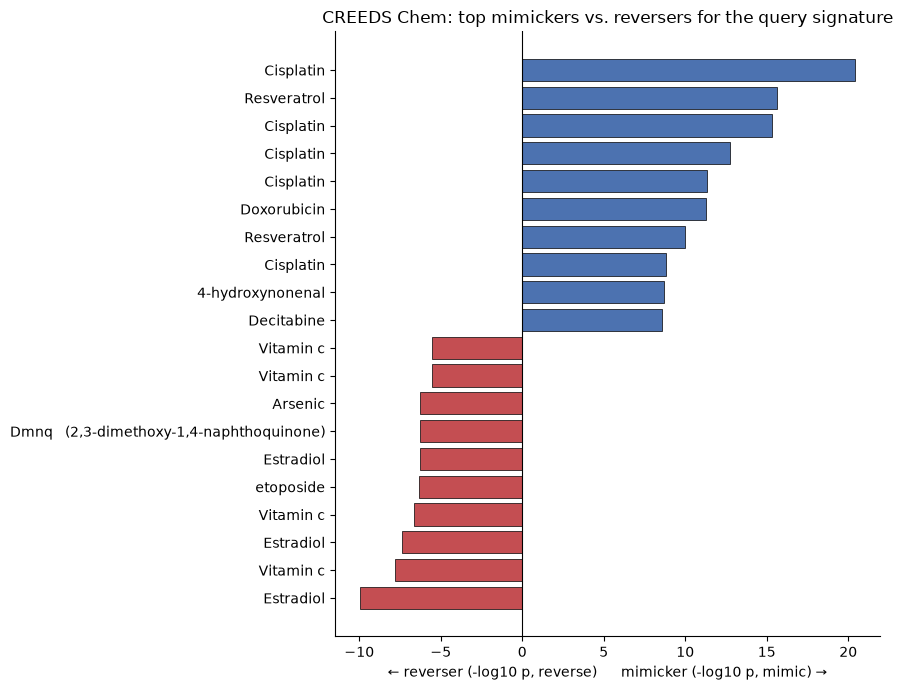

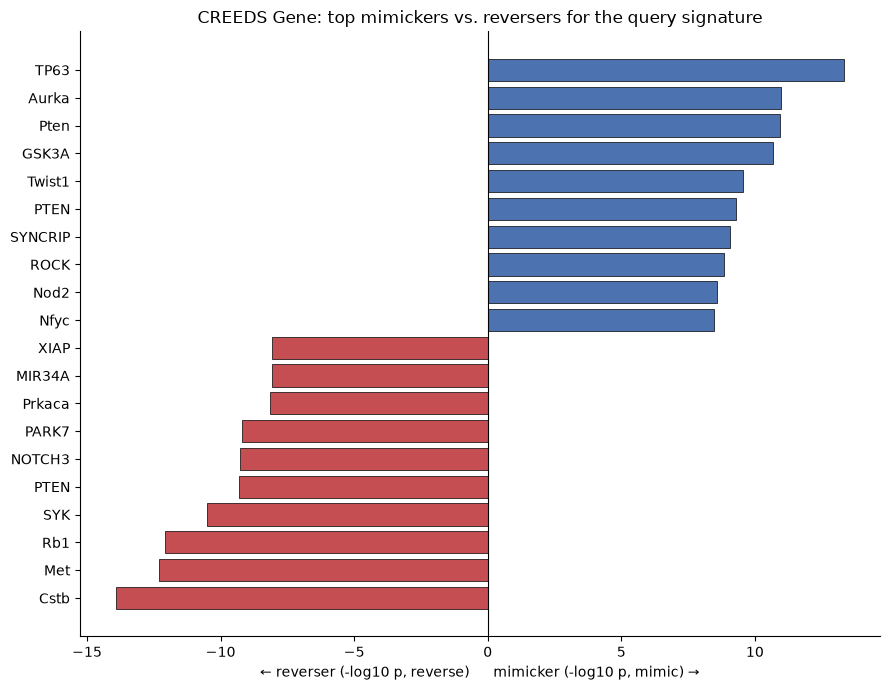

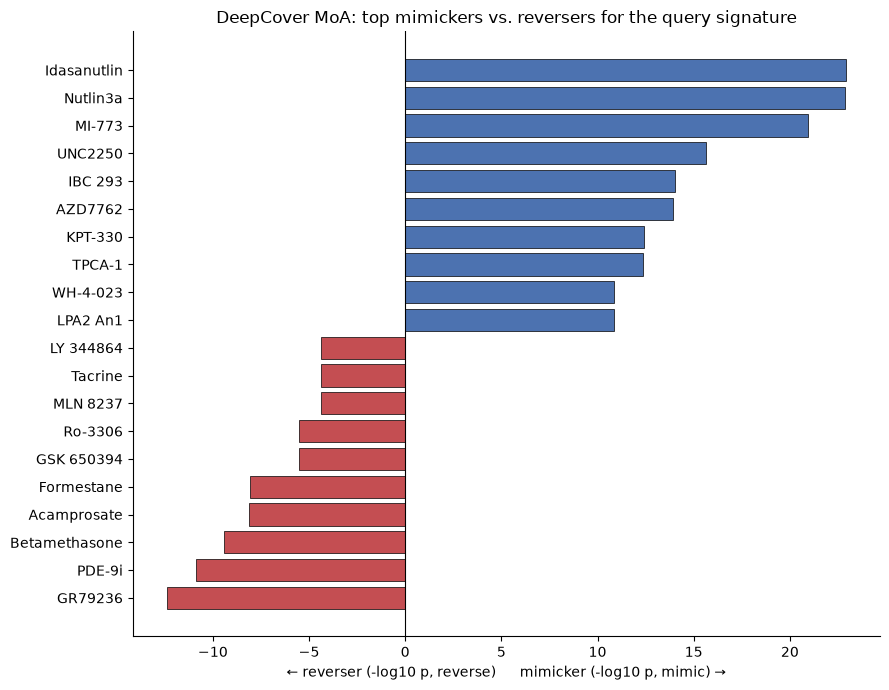

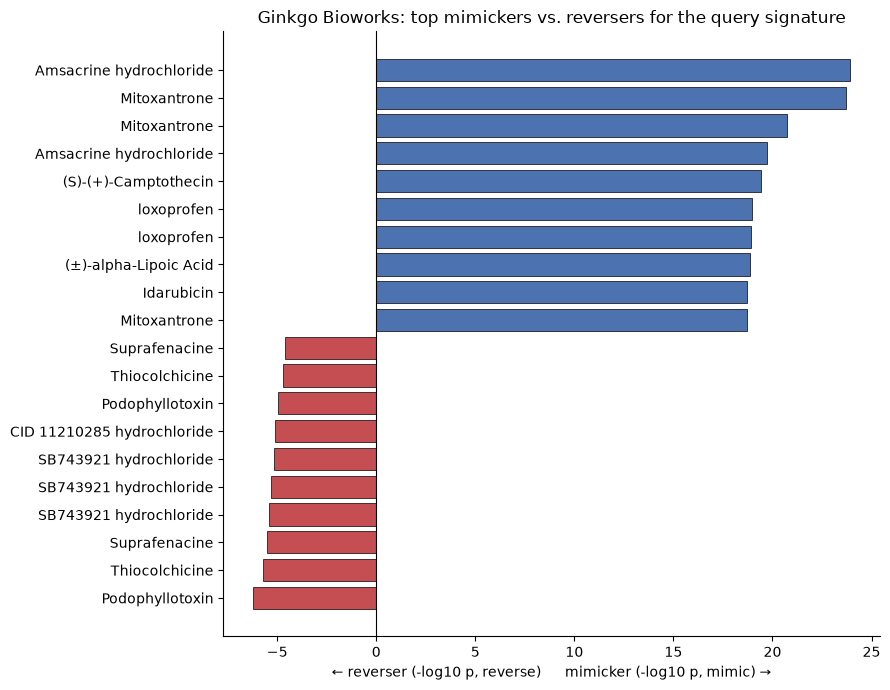

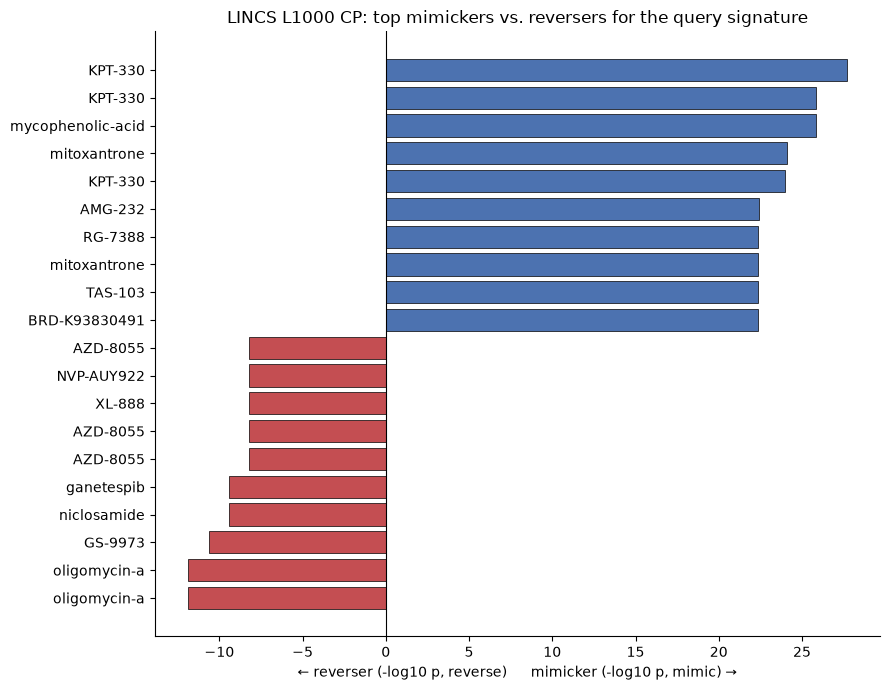

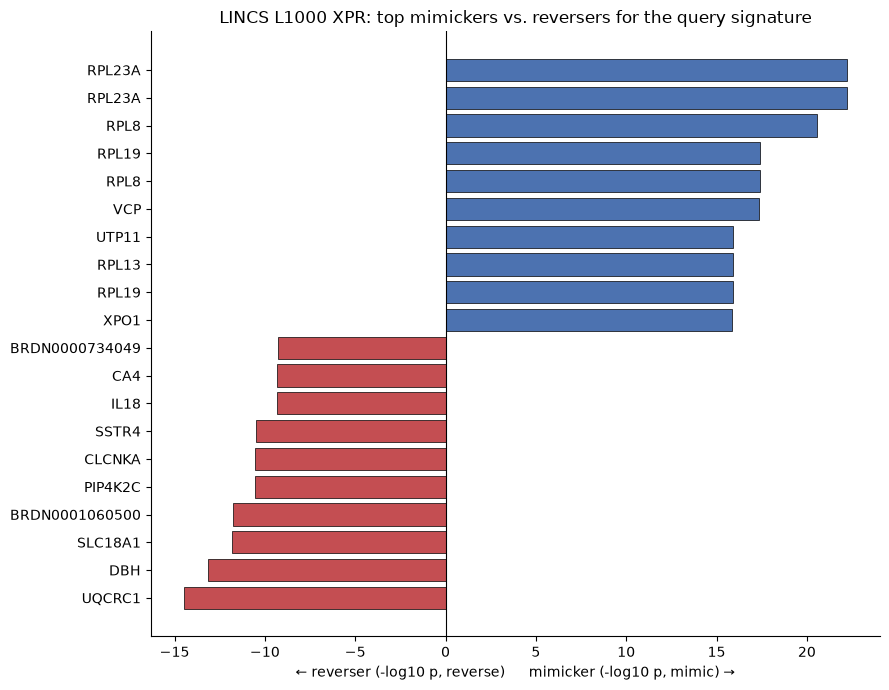

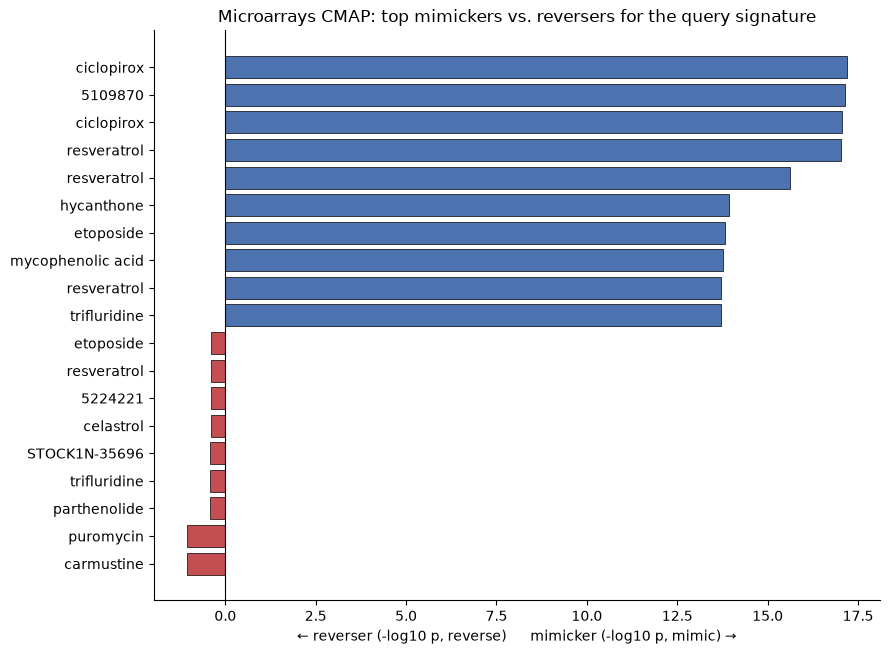

/var/folders/wx/60dd_d991tvbb_jrht5ps69m0000gn/T/ipykernel_66424/3633925628.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


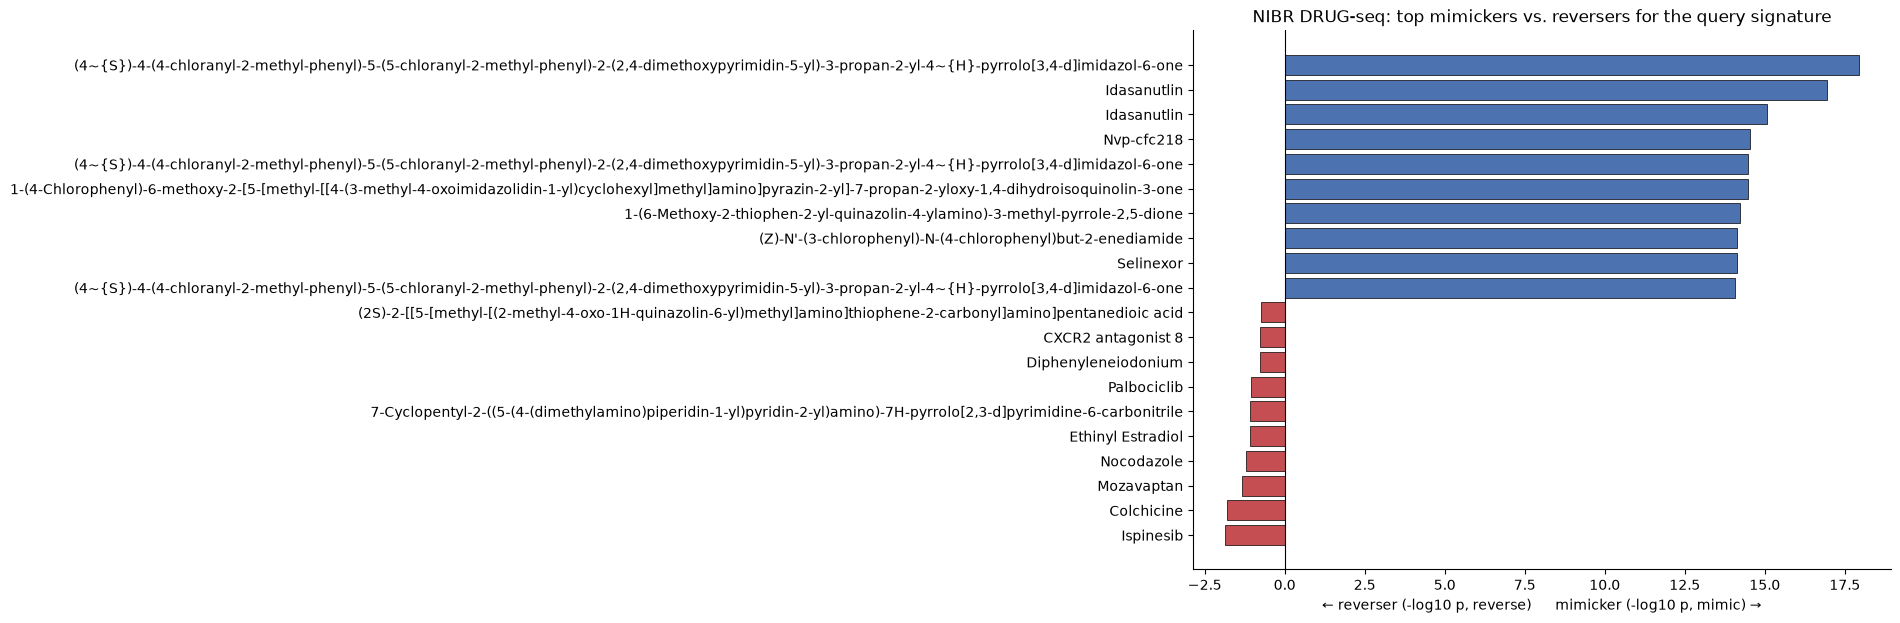

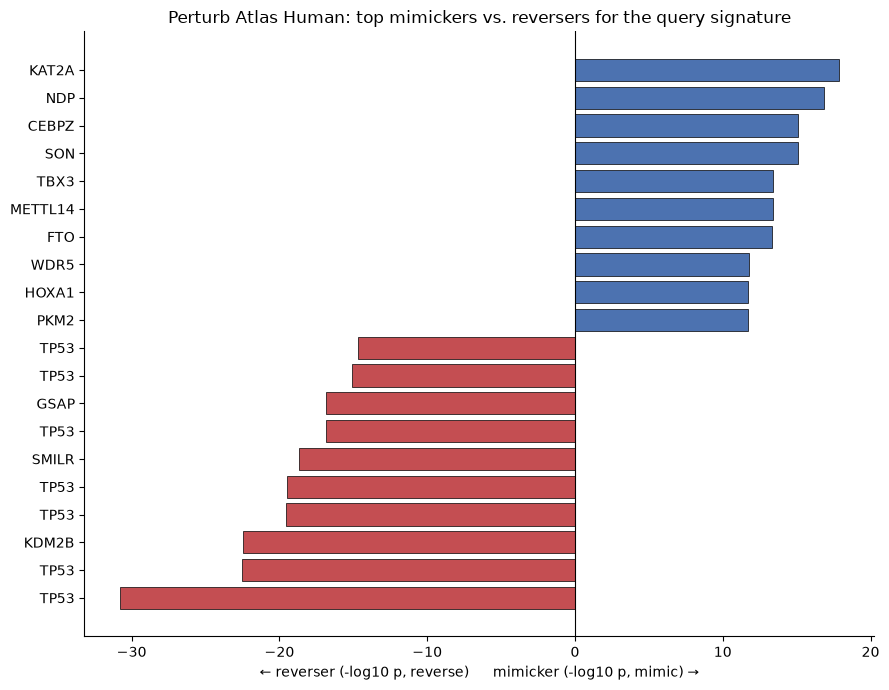

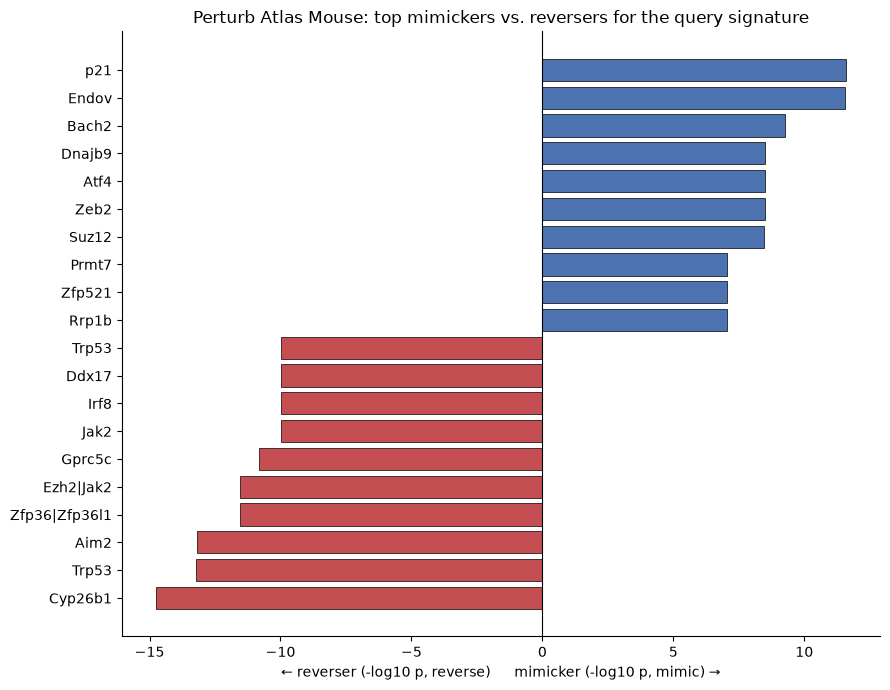

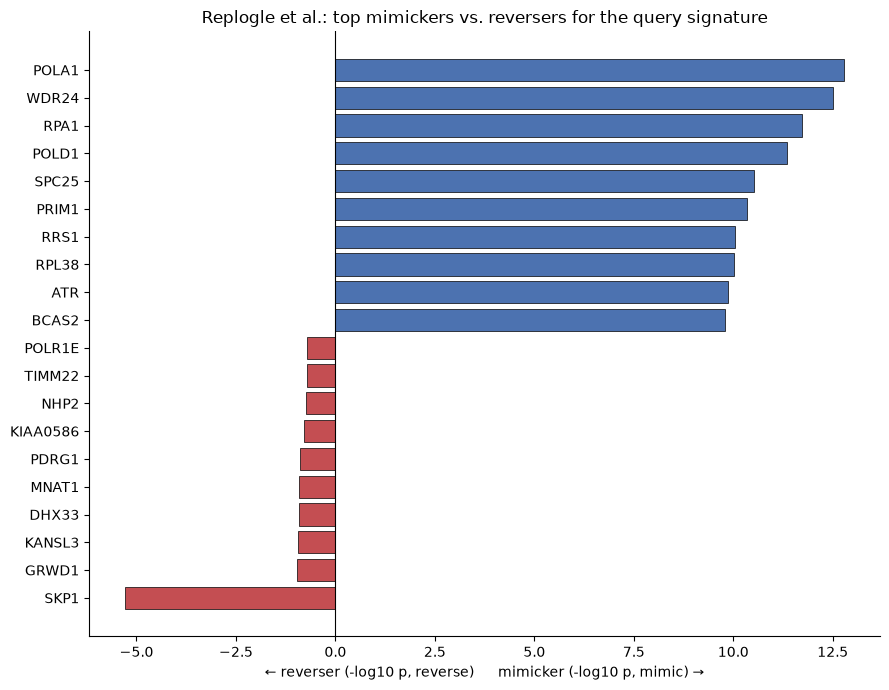

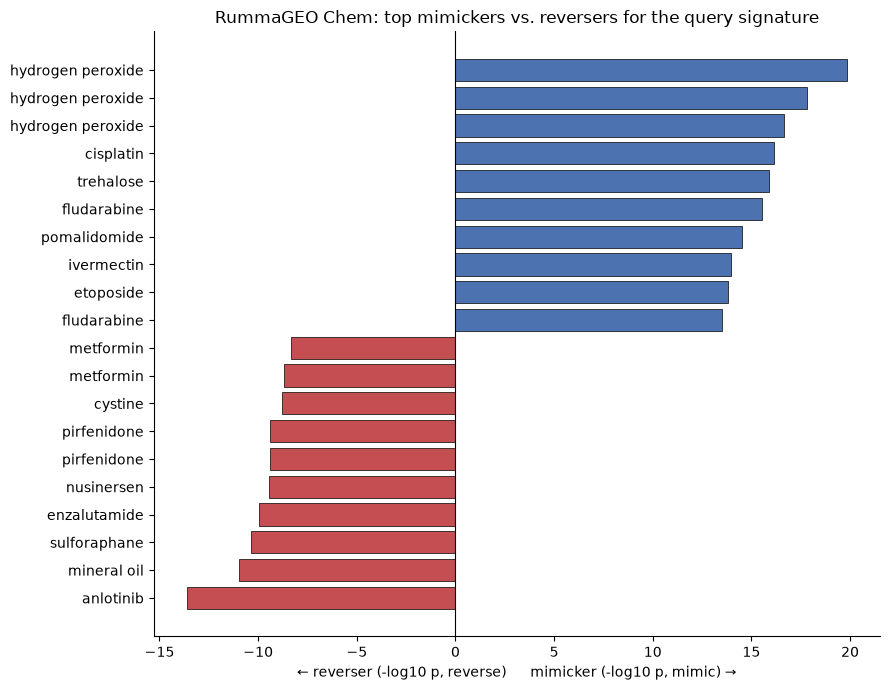

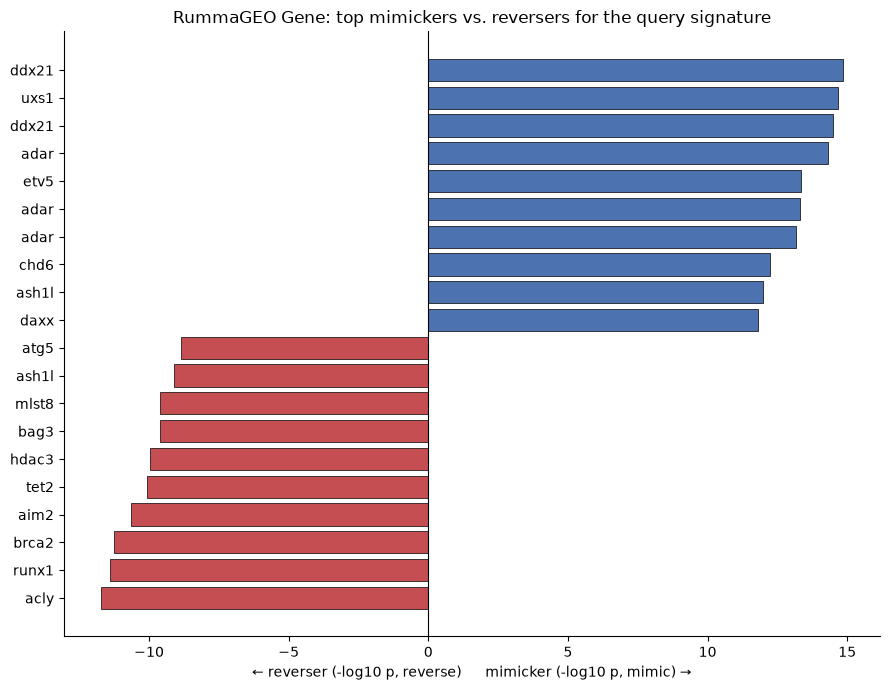

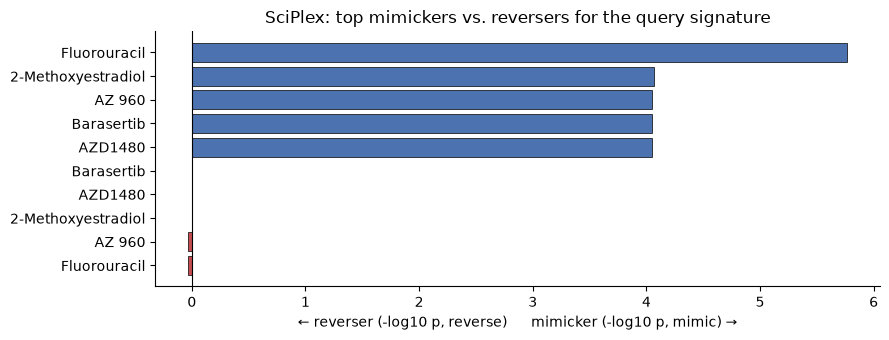

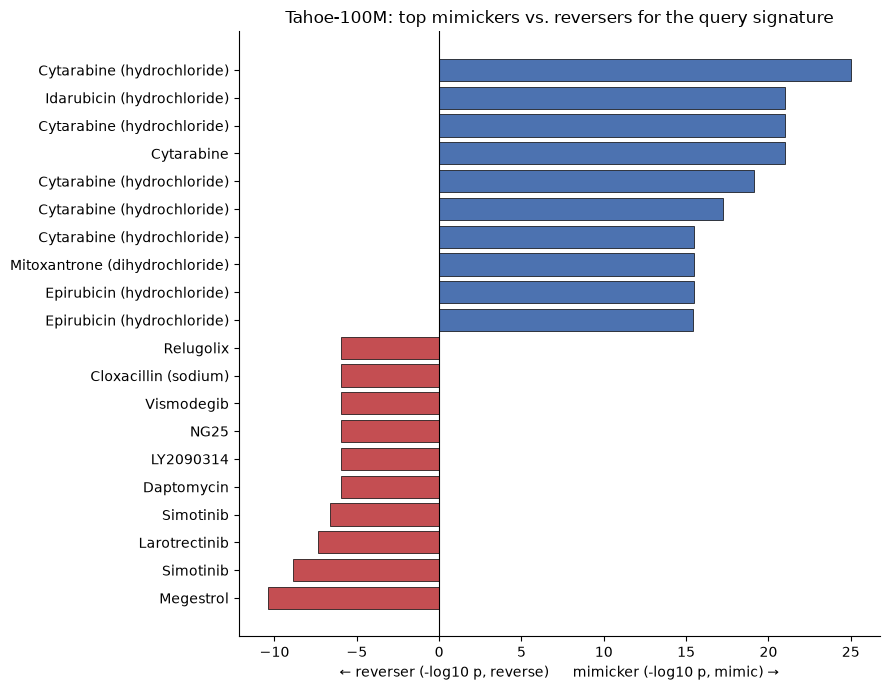

In [25]:
def make_perturbseqr_diverging_chart(library, df, top_n=10):
    """Diverging bar chart for one Perturb-Seqr library: top reversers (red, negative,
    extending left) vs. top mimickers (blue, positive, extending right)."""
    lib_df = df[df["library"] == library] if not df.empty else df

    mim = lib_df.dropna(subset=["pvalueMimic"]).sort_values("pvalueMimic").head(top_n) if not lib_df.empty else lib_df
    rev = lib_df.dropna(subset=["pvalueReverse"]).sort_values("pvalueReverse").head(top_n) if not lib_df.empty else lib_df

    if mim.empty and rev.empty:
        return False

    mim_scores = -np.log10(mim["pvalueMimic"].clip(lower=1e-300)) if not mim.empty else pd.Series(dtype=float)
    rev_scores = np.log10(rev["pvalueReverse"].clip(lower=1e-300)) if not rev.empty else pd.Series(dtype=float)  # already negative

    # Reversers: most significant (most negative) farthest from zero, so plot from the
    # strongest outward -- ascending score puts the most negative first (top of chart).
    rev_order = rev_scores.sort_values(ascending=True).index if not rev.empty else []
    mim_order = mim_scores.sort_values(ascending=True).index if not mim.empty else []

    labels = [rev.loc[i, "term"] for i in rev_order] + [mim.loc[i, "term"] for i in mim_order]
    scores = [rev_scores.loc[i] for i in rev_order] + [mim_scores.loc[i] for i in mim_order]
    colors = ["#C44E52"] * len(rev_order) + ["#4C72B0"] * len(mim_order)

    fig_h = max(3, 0.35 * len(labels))
    plt.figure(figsize=(9, fig_h))
    ax = plt.gca()
    ax.barh(range(len(labels)), scores, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("\u2190 reverser (-log10 p, reverse)      mimicker (-log10 p, mimic) \u2192")
    ax.set_title(f"{library}: top mimickers vs. reversers for the query signature")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    plt.tight_layout()

    safe_name = library.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(f"perturbseqr_{safe_name}_mimic_vs_reverse_bar.png", bbox_inches="tight")
    plt.show()
    return True


libraries = sorted(df_enrichment_pair["library"].dropna().unique()) if not df_enrichment_pair.empty else []

# Diagnostic: a library is skipped below only if it has zero rows with a non-null
# pvalueMimic AND zero rows with a non-null pvalueReverse. Print per-library counts so it's
# clear whether a missing chart means "no significant hits in the top-1000 window" (expected,
# not a bug) vs. something else. Also flag any library name containing "sciplex"
# case-insensitively, in case the live API's exact label differs in casing/spacing from what
# might be expected (e.g. "SciPlex" vs "SciPlex Chem").
if not df_enrichment_pair.empty:
    lib_counts = df_enrichment_pair.groupby("library").agg(
        n_rows=("library", "size"),
        n_mimic=("pvalueMimic", lambda s: s.notna().sum()),
        n_reverse=("pvalueReverse", lambda s: s.notna().sum()),
    )
    print("Per-library row/coverage counts in df_enrichment_pair:")
    print(lib_counts)

for library in libraries:
    made = make_perturbseqr_diverging_chart(library, df_enrichment_pair, top_n=10)
    if not made:
        print(f"Skipped chart for '{library}': no rows with a non-null pvalueMimic or pvalueReverse.")

## Summary

1. Queried Perturb-Seqr's paired up/down enrichment endpoint for **`GENES_UP`**/**`GENES_DOWN`**.
2. Classified every resulting perturbation as a **drug/chemical** or **gene** perturbation based on which dataset/library it was found in.
3. Reported top **drug mimickers**, **gene mimickers**, **drug reversers**, and **gene reversers** — both as robust consensus hits and as individual per-dataset hits (comparable to the website's default table).
4. Visualized the individual (per-dataset) mimickers and reversers as a diverging bar chart for each Perturb-Seqr library.

Swap in your own `GENES_UP`/`GENES_DOWN` signature at the top to analyze a different up/down gene set.